# Home Credit Default Risk Prediction

This project aims to predict whether a client will default on a loan using the
Home Credit dataset. The dataset contains multiple relational tables describing
clients' financial history.

## Project Workflow

The workflow of this project follows a structured machine learning pipeline
for credit default prediction.

### 1. Data Loading
Load the main application dataset and all related auxiliary tables,
including bureau records, previous applications, POS cash balances,
credit card balances, and installment payments.

### 2. Data Understanding
Explore the datasets to understand the structure, feature types,
and the presence of missing values.

### 3. Feature Engineering
Create new client-level features by aggregating information from
the auxiliary tables. This includes:

- Bureau credit history features
- Previous application behavior
- POS loan information
- Credit card usage patterns
- Installment payment behavior

### 4. Dataset Construction
Merge all engineered features with the main application dataset
to create a single modeling table.

### 5. Data Preprocessing
Prepare the dataset for modeling by:

- handling missing values
- removing highly sparse columns
- creating missing-value indicators
- imputing numerical and categorical variables

### 6. Encoding Categorical Variables
Convert categorical features into numerical format using one-hot encoding.

### 7. Modeling Preparation
Prepare the data for training by:

- analyzing target class distribution
- splitting the dataset into train, validation, and test sets
- computing sample weights to address class imbalance

### 8. Model Training
Train multiple machine learning models, including:

- Logistic Regression
- Decision Tree
- Random Forest
- XGBoost

### 9. Model Evaluation And Hyperparameter tuning
Evaluate model performance using multiple metrics:

- ROC-AUC
- Precision
- Recall
- F1-score
- Confusion Matrix

### 10. Model Comparison
Compare the performance of different models to identify
the most effective approach for credit default prediction.

### 11. Error Analysis
Analyze prediction errors (false positives and false negatives)
to better understand model limitations and potential improvements.

## Mount Google Drive

Since the dataset is stored in Google Drive, we mount the drive to access the files from the Colab environment.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Import Required Libraries

In this section we import the libraries used for data processing,
visualization, and machine learning.

In [ ]:
# =========================================================
# Standard libraries
# =========================================================
import re                           # Regular expressions for cleaning and renaming column names

# =========================================================
# Core data manipulation libraries
# =========================================================
import numpy as np                  # Numerical operations and array-based computations
import pandas as pd                 # Data loading, cleaning, transformation, and tabular analysis

# =========================================================
# Visualization libraries
# =========================================================
import matplotlib.pyplot as plt     # General plotting library for charts and curves
import seaborn as sns               # Statistical visualization, especially heatmaps

# =========================================================
# Preprocessing utilities
# =========================================================
from sklearn.impute import SimpleImputer         # Impute missing numerical and categorical values
from sklearn.preprocessing import StandardScaler # Scale features for models sensitive to magnitude

# =========================================================
# Data splitting and validation
# =========================================================
from sklearn.model_selection import (
    train_test_split,               # Split data into train, validation, and test sets
    StratifiedKFold,                # Stratified cross-validation to preserve class balance
    cross_val_score                 # Evaluate model performance using cross-validation
)

# =========================================================
# Machine learning pipelines
# =========================================================
from sklearn.pipeline import Pipeline            # Build reusable preprocessing + modeling pipelines

# =========================================================
# Machine learning models
# =========================================================
from sklearn.linear_model import LogisticRegression   # Linear baseline classifier
from sklearn.tree import DecisionTreeClassifier       # Single tree-based classification model
from sklearn.ensemble import RandomForestClassifier   # Ensemble of decision trees for more robust performance
from xgboost import XGBClassifier                     # Gradient boosting model for high-performance tabular learning

# =========================================================
# XGBoost training utilities
# =========================================================
from xgboost.callback import LearningRateScheduler    # Dynamically adjust learning rate during boosting

# =========================================================
# Evaluation metrics
# =========================================================
from sklearn.metrics import (
    roc_auc_score,                # Main evaluation metric for binary classification ranking performance
    precision_score,             # Precision of predicted positive class
    recall_score,                # Recall of the positive class
    f1_score,                    # Harmonic mean of precision and recall
    confusion_matrix,            # Confusion matrix for classification outcomes
    classification_report,       # Full text summary of classification metrics
    roc_curve,                   # ROC curve coordinates
    precision_recall_curve       # Precision-Recall curve coordinates
)

## Extract Dataset

The Home Credit dataset is stored as a compressed ZIP file in Google Drive.
In this step, we extract the dataset to a working directory inside the Colab
environment so that the CSV files can be accessed and loaded with pandas.

In [ ]:
import zipfile

# Path to the compressed dataset stored in Google Drive
zip_path = "/content/drive/MyDrive/home-credit-default-risk.zip"

# Directory where the dataset will be extracted
extract_path = "/content/home_credit_data"

# Extract all files from the zip archive
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# Confirm extraction
print("Done extracting!")

Done extracting!


## Load Dataset

The Home Credit dataset consists of multiple relational tables.
Each table describes different aspects of a client's credit history.

Main tables used in this project:

- **application_train**: Main dataset containing loan applications and the target variable.
- **bureau**: Information about previous loans from other financial institutions.
- **previous_application**: Historical loan applications.
- **POS_CASH_balance**: Monthly balance snapshots of POS and cash loans.
- **installments_payments**: Repayment history of previous credits.
- **credit_card_balance**: Monthly credit card balance information.

These tables will later be used to create engineered features.

In [ ]:
# Directory where the dataset was extracted
path = "/content/home_credit_data/"

# Load the main application dataset (contains target variable)
Data = pd.read_csv(path + "application_train.csv")

# Load bureau table (credit history from other financial institutions)
bureau = pd.read_csv(path + "bureau.csv")

# Load previous loan applications
previous = pd.read_csv(path + "previous_application.csv")

# Load POS and cash loan balance information
pos = pd.read_csv(path + "POS_CASH_balance.csv")

# Load installment payment history
installments = pd.read_csv(path + "installments_payments.csv")

# Load credit card monthly balance data
cc = pd.read_csv(path + "credit_card_balance.csv")

# Display the shape of the main dataset
print("Data shape:", Data.shape)

Data shape: (307511, 122)


### Handling Missing Values After Aggregation

Some columns in the auxiliary tables (e.g., the **bureau** table) contain missing
values in the original data. When aggregation operations such as `mean`, `sum`,
or `max` are applied, the resulting aggregated features may still contain
missing values if all records for a client are missing for that variable.

To preserve potential information carried by missing values, a **missing flag**
feature was created before aggregation. This flag indicates whether the
original variable contained missing values for a given record, and the number
of missing occurrences is aggregated per client.

Note: the missing-flag strategy was applied only to features that still contained
null values after the aggregation step.

In this project, missing values were not handled at the raw-table level for
every auxiliary dataset. This is because aggregation functions such as `mean`,
`max`, and `min` naturally ignore null values. For example, if a client has
three previous loans and two of them contain null values for a specific
variable, these null values are ignored and the aggregation is computed from
the remaining valid value. This approach keeps the process simpler and avoids
introducing artificial values before aggregation.

For this reason, aggregation functions like `mean`, `min`, and `max` were
preferred, while `sum` was used more cautiously(Mostly on variables that have not null), since summing values when
many records are missing could introduce bias or produce misleading results.

After feature aggregation and merging, any remaining missing values are replaced
with **0** to ensure the dataset remains suitable for machine learning models.

## Bureau Feature Engineering

The `bureau` table contains information about the client's previous credits
from other financial institutions.

In this step, we create aggregated features at the client level (`SK_ID_CURR`)
to summarize:

- the number of previous bureau loans,
- overdue behavior,
- credit prolongation history,
- total debt exposure,
- counts of active credit statuses,
- counts of credit types,
- missing debt information.

These features help capture the client's external credit profile and repayment risk.

In [ ]:
def create_bureau_features(bureau: pd.DataFrame) -> pd.DataFrame:
    """
    Create aggregated client-level features from the bureau table.

    This function summarizes each client's external credit history by
    generating numerical aggregation features, active credit status counts,
    credit type counts, and a missing-debt indicator.

    Parameters
    ----------
    bureau : pd.DataFrame
        Raw bureau table containing previous credit records from external
        financial institutions.

    Returns
    -------
    pd.DataFrame
        A feature table grouped by `SK_ID_CURR`, where each row represents
        one client and each column is an engineered bureau-based feature.
    """

    # Aggregate core numerical bureau statistics for each client
    bureau_num = bureau.groupby("SK_ID_CURR").agg(
        BUREAU_LOAN_COUNT=("SK_ID_BUREAU", "count"),
        BUREAU_OVERDUE_DAYS_SUM=("CREDIT_DAY_OVERDUE", "sum"),
        BUREAU_OVERDUE_DAYS_MAX=("CREDIT_DAY_OVERDUE", "max"),
        BUREAU_PROLONG_SUM=("CNT_CREDIT_PROLONG", "sum"),
        BUREAU_PROLONG_MAX=("CNT_CREDIT_PROLONG", "max"),
        BUREAU_DEBT_SUM=("AMT_CREDIT_SUM_DEBT", "mean"),
    ).reset_index()

    # Count the number of bureau records for each credit status per client
    active_counts = (
        bureau.pivot_table(
            index="SK_ID_CURR",
            columns="CREDIT_ACTIVE",
            values="SK_ID_BUREAU",
            aggfunc="count",
            fill_value=0
        ).reset_index()
    )

    # Count the number of bureau records for each credit type per client
    credit_type_counts = (
        bureau.pivot_table(
            index="SK_ID_CURR",
            columns="CREDIT_TYPE",
            values="SK_ID_BUREAU",
            aggfunc="count",
            fill_value=0
        ).reset_index()
    )

    # Rename credit type columns to make their meaning explicit
    type_cols = [c for c in credit_type_counts.columns if c != "SK_ID_CURR"]
    credit_type_counts.rename(
        columns={c: f"BUREAU_CREDIT_TYPE_{str(c).upper().replace(' ', '_')}" for c in type_cols},
        inplace=True
    )

    # Rename active status columns to make their meaning explicit
    active_cols = [c for c in active_counts.columns if c != "SK_ID_CURR"]
    active_counts.rename(
        columns={c: f"BUREAU_ACTIVE_{c.upper().replace(' ', '_')}" for c in active_cols},
        inplace=True
    )

    # Create a flag indicating whether debt value is missing in each bureau record
    bureau["DEBT_MISSING_FLAG"] = bureau["AMT_CREDIT_SUM_DEBT"].isnull().astype(int)

    # Aggregate the number of missing debt records for each client
    bureau_missing = bureau.groupby("SK_ID_CURR").agg(
        BUREAU_DEBT_MISSING_COUNT=("DEBT_MISSING_FLAG", "sum")
    ).reset_index()

    # Merge all engineered bureau features into a single client-level table
    bureau_features = (
        bureau_num
        .merge(active_counts, on="SK_ID_CURR", how="left")
        .merge(credit_type_counts, on="SK_ID_CURR", how="left")
        .merge(bureau_missing, on="SK_ID_CURR", how="left")
    )

    # Fill missing values in engineered features after merging
    cols_to_fill = bureau_features.columns.drop("SK_ID_CURR")
    bureau_features[cols_to_fill] = bureau_features[cols_to_fill].fillna(0)

    return bureau_features

## Previous Applications Feature Engineering

The `previous_application` table contains information about the client's past
loan applications submitted to Home Credit.

In this step, we create client-level features that summarize:

- the total number of previous applications,
- the distribution of application statuses,
- down payment statistics,
- interest rate statistics,
- insurance usage on approved applications,
- reject reason counts,
- missing down payment information.

These features help describe the client's previous borrowing behavior and
application history.

In [ ]:
def create_prev_features(previous: pd.DataFrame) -> pd.DataFrame:
    """
    Create aggregated client-level features from the previous applications table.

    This function summarizes each client's historical loan application behavior
    by generating counts of previous applications, application status counts,
    reject reason counts, numerical aggregations for payment and interest
    variables, and a missing-value indicator for down payment.

    Parameters
    ----------
    previous : pd.DataFrame
        Raw previous application table containing historical loan applications.

    Returns
    -------
    pd.DataFrame
        A feature table grouped by `SK_ID_CURR`, where each row represents
        one client and each column is an engineered feature derived from
        previous applications.
    """

    # Count the total number of previous applications for each client
    prev_count = previous.groupby("SK_ID_CURR").agg(
        PREV_TOTAL_APPLICATIONS=("SK_ID_PREV", "count")
    ).reset_index()

    # Count application statuses for each client
    status_counts = (
        previous.pivot_table(
            index="SK_ID_CURR",
            columns="NAME_CONTRACT_STATUS",
            values="SK_ID_PREV",
            aggfunc="count",
            fill_value=0
        ).reset_index()
    )

    # Rename status columns for clarity
    status_cols = [c for c in status_counts.columns if c != "SK_ID_CURR"]
    status_counts.rename(
        columns={c: f"PREV_STATUS_{str(c).upper().replace(' ', '_')}" for c in status_cols},
        inplace=True
    )

    # Aggregate numerical information related to down payment, interest rates,
    # and insurance usage across previous applications
    prev_num = previous.groupby("SK_ID_CURR").agg(
        PREV_DOWNPAYMENT_MEAN=("RATE_DOWN_PAYMENT", "mean"),
        PREV_DOWNPAYMENT_MAX=("RATE_DOWN_PAYMENT", "max"),

        PREV_INTEREST_PRIMARY_MEAN=("RATE_INTEREST_PRIMARY", "mean"),
        PREV_INTEREST_PRIMARY_MAX=("RATE_INTEREST_PRIMARY", "max"),

        PREV_INTEREST_PRIVILEGED_MEAN=("RATE_INTEREST_PRIVILEGED", "mean"),
        PREV_INTEREST_PRIVILEGED_MAX=("RATE_INTEREST_PRIVILEGED", "max"),

        PREV_INSURED_SUM=("NFLAG_INSURED_ON_APPROVAL", "sum"),
        PREV_INSURED_MEAN=("NFLAG_INSURED_ON_APPROVAL", "mean"),
    ).reset_index()

    # Count reject reasons for each client
    reject_counts = (
        previous.pivot_table(
            index="SK_ID_CURR",
            columns="CODE_REJECT_REASON",
            values="SK_ID_PREV",
            aggfunc="count",
            fill_value=0
        ).reset_index()
    )

    # Rename reject reason columns for clarity
    reject_cols = [c for c in reject_counts.columns if c != "SK_ID_CURR"]
    reject_counts.rename(
        columns={c: f"PREV_REJECT_{str(c).upper().replace(' ', '_')}" for c in reject_cols},
        inplace=True
    )

    # Create a missing-value flag for down payment
    previous["DOWNPAYMENT_MISSING_FLAG"] = previous["RATE_DOWN_PAYMENT"].isnull().astype(int)

    # Count the number of missing down payment values for each client
    downpayment_missing = previous.groupby("SK_ID_CURR").agg(
        PREV_DOWNPAYMENT_MISSING_COUNT=("DOWNPAYMENT_MISSING_FLAG", "sum")
    ).reset_index()

    # Merge all previous-application feature groups into a single client-level table
    prev_features = (
        prev_count
        .merge(status_counts, on="SK_ID_CURR", how="left")
        .merge(prev_num, on="SK_ID_CURR", how="left")
        .merge(reject_counts, on="SK_ID_CURR", how="left")
        .merge(downpayment_missing, on="SK_ID_CURR", how="left")
    )

    # Fill missing values introduced during feature merging
    cols_to_fill = prev_features.columns.drop("SK_ID_CURR")
    prev_features[cols_to_fill] = prev_features[cols_to_fill].fillna(0)

    return prev_features

## POS Cash Balance Feature Engineering

The `POS_CASH_balance` table contains monthly snapshots of the client's
Point-of-Sale (POS) and cash loan balances.

Each record represents the status of a loan at a specific month.

In this step we generate client-level features that summarize:

- the number of POS loans,
- delinquency behavior (days past due),
- late payment occurrences,
- statistics about remaining installments,
- missing information about future installments.

These features help capture repayment behavior and loan progression over time.

In [ ]:
def create_pos_features(pos: pd.DataFrame) -> pd.DataFrame:
    """
    Create aggregated client-level features from the POS_CASH_balance table.

    The POS_CASH_balance dataset contains monthly snapshots describing the
    status of the client's point-of-sale (POS) and cash loans. Each record
    represents the loan status at a specific month.

    This function summarizes the client's POS loan behavior by generating
    aggregated statistics related to delinquency, installment progression,
    and missing information about future installments.

    Parameters
    ----------
    pos : pd.DataFrame
        Raw POS_CASH_balance table containing monthly POS loan records.

    Returns
    -------
    pd.DataFrame
        A client-level feature table grouped by `SK_ID_CURR`, where each row
        corresponds to one client and each column represents an engineered
        feature derived from POS loan history.
    """

    # Create a flag indicating whether the number of remaining installments is missing
    pos["FUTURE_INST_MISSING_FLAG"] = pos["CNT_INSTALMENT_FUTURE"].isnull().astype(int)

    # Count how many times the future installment value is missing for each client
    pos_missing = pos.groupby("SK_ID_CURR").agg(
        POS_FUTURE_INST_MISSING_COUNT=("FUTURE_INST_MISSING_FLAG", "sum")
    ).reset_index()

    # Aggregate POS loan statistics for each client
    pos_features = pos.groupby("SK_ID_CURR").agg(

        # Number of unique POS loans taken by the client
        POS_LOAN_COUNT=("SK_ID_PREV", "nunique"),

        # Delinquency statistics (days past due)
        POS_DPD_MEAN=("SK_DPD", "mean"),
        POS_DPD_MAX=("SK_DPD", "max"),

        # Count how many months the client had late payments
        POS_LATE_MONTHS=("SK_DPD", lambda x: (x > 0).sum()),

        # Statistics of remaining installments
        POS_FUTURE_INST_MEAN=("CNT_INSTALMENT_FUTURE", "mean"),
        POS_FUTURE_INST_MAX=("CNT_INSTALMENT_FUTURE", "max"),
        POS_FUTURE_INST_MIN=("CNT_INSTALMENT_FUTURE", "min"),

    ).reset_index()

    # Merge missing-value feature with main POS features
    pos_features = pos_features.merge(pos_missing, on="SK_ID_CURR", how="left")

    # Fill missing values that may appear after merging
    pos_features[pos_features.columns.drop("SK_ID_CURR")] = pos_features[
        pos_features.columns.drop("SK_ID_CURR")
    ].fillna(0)

    return pos_features

## Credit Card Balance Feature Engineering

The `credit_card_balance` table contains monthly snapshots of the client's
credit card balances.

It describes how the client uses and repays credit card debt.

In this step we create aggregated features capturing:

- receivable balance statistics,
- minimum installment behavior,
- delinquency indicators,
- missing installment information.

These features help characterize the client's credit card usage
and repayment discipline.

In [ ]:
def create_cc_features(cc: pd.DataFrame) -> pd.DataFrame:
    """
    Create aggregated client-level features from the credit_card_balance table.

    The credit_card_balance dataset contains monthly snapshots of each client's
    credit card balances and repayment behavior.

    This function summarizes credit card usage by generating statistical
    features related to receivable balances, minimum installment requirements,
    delinquency indicators, and missing installment information.

    Parameters
    ----------
    cc : pd.DataFrame
        Raw credit_card_balance table containing monthly credit card records.

    Returns
    -------
    pd.DataFrame
        A client-level feature table grouped by `SK_ID_CURR`, where each row
        represents one client and each column corresponds to an engineered
        credit card feature.
    """

    # Aggregate credit card balance statistics for each client
    cc_features = cc.groupby("SK_ID_CURR").agg(

        # Average and maximum total receivable balance
        CC_TOTAL_RECEIVABLE_MEAN=("AMT_TOTAL_RECEIVABLE", "mean"),
        CC_TOTAL_RECEIVABLE_MAX=("AMT_TOTAL_RECEIVABLE", "max"),

        # Average minimum installment required for credit card repayment
        CC_MIN_INST_MEAN=("AMT_INST_MIN_REGULARITY", "mean"),

        # Delinquency statistics indicating late credit card payments
        CC_DPD_DEF_MEAN=("SK_DPD_DEF", "mean"),
        CC_DPD_DEF_MAX=("SK_DPD_DEF", "max"),

    ).reset_index()

    # Create a flag indicating missing minimum installment values
    cc["MIN_INST_MISSING_FLAG"] = cc["AMT_INST_MIN_REGULARITY"].isnull().astype(int)

    # Count how many credit card records have missing installment information
    cc_missing = cc.groupby("SK_ID_CURR").agg(
        CC_MIN_INST_MISSING_COUNT=("MIN_INST_MISSING_FLAG", "sum")
    ).reset_index()

    # Merge missing-value feature with aggregated features
    cc_features = cc_features.merge(cc_missing, on="SK_ID_CURR", how="left")

    return cc_features

## Installment Payments Feature Engineering

The `installments_payments` table contains historical records describing how
clients repaid their previous loans.

Each record includes:
- the expected installment amount,
- the actual payment made,
- the scheduled payment date,
- the actual payment date.

From this table we create behavioral features that capture:

- payment delays (days past due),
- payment ratio (how much was paid relative to the expected installment),
- the number of installment records per client.

These features help describe the client's repayment discipline and financial behavior.

In [ ]:
def create_installments_features(installments: pd.DataFrame) -> pd.DataFrame:
    """
    Create aggregated client-level features from the installments_payments table.

    The installments_payments dataset contains historical records of loan
    installment payments. Each record describes the expected installment
    amount, the actual payment made, and the timing of the payment.

    This function generates behavioral features describing how clients repay
    their previous loans. It captures late payment behavior, payment ratios,
    and the number of installments associated with each client.

    Parameters
    ----------
    installments : pd.DataFrame
        Raw installments_payments table containing payment history.

    Returns
    -------
    pd.DataFrame
        A client-level feature table grouped by `SK_ID_CURR`, where each row
        corresponds to one client and each column represents an engineered
        feature derived from installment payment behavior.
    """

    # Remove rows where the actual payment value is missing
    '''I choose this way beacause number of missing values is small'''
    installments = installments.dropna(subset=["AMT_PAYMENT", "AMT_INSTALMENT"]).copy()

    # Calculate payment delay (difference between actual payment date and expected date)
    installments["DPD"] = installments["DAYS_ENTRY_PAYMENT"] - installments["DAYS_INSTALMENT"]

    # Calculate payment ratio (how much the client paid compared to the expected installment)
    installments["PAY_RATIO"] = np.where(
        installments["AMT_INSTALMENT"] > 0,
        installments["AMT_PAYMENT"] / installments["AMT_INSTALMENT"],
        0
    )

    # Aggregate installment behavior statistics per client
    inst_features = installments.groupby("SK_ID_CURR").agg(

        # Number of installment payments recorded for the client
        INST_COUNT=("AMT_INSTALMENT", "count"),

        # Average delay in payments
        INST_DPD_MEAN=("DPD", "mean"),

        # Maximum delay in payments
        INST_DPD_MAX=("DPD", "max"),

        # Average payment ratio
        INST_PAY_RATIO_MEAN=("PAY_RATIO", "mean"),

    ).reset_index()

    return inst_features

## Handling Missing Values After Feature Merging

When feature tables are merged with the main dataset, some clients may not
have records in certain tables.

For example:
- a client may never have used a credit card,
- a client may not have POS loans,
- a client may not have previous applications.

In such cases, the merged feature columns contain missing values.

This helper function replaces these missing values with zero, ensuring that
the dataset remains consistent and suitable for machine learning models.

In [ ]:
def fill_merged_features_zero(df_merged, feat_df, id_col="SK_ID_CURR"):
    """
    Fill missing values created after merging feature tables.

    When feature tables are merged into the main dataset, some clients may
    not have corresponding records in certain tables. This results in NaN
    values for those engineered features.

    This function replaces those missing values with zeros for all columns
    that originate from the merged feature table.

    Parameters
    ----------
    df_merged : pd.DataFrame
        The main dataset after merging a feature table.

    feat_df : pd.DataFrame
        The feature table that was merged into the dataset.

    id_col : str, default="SK_ID_CURR"
        The column used as the client identifier.

    Returns
    -------
    pd.DataFrame
        The dataset with missing values from merged features replaced by zero.
    """

    # Identify feature columns from the merged table
    cols = feat_df.columns.tolist()

    # Replace missing values with zero for all feature columns except the ID
    for col in cols:
        if col != id_col:
            df_merged[col] = df_merged[col].fillna(0)

    return df_merged

## Build Final Modeling Dataset

The Home Credit dataset consists of multiple relational tables describing
different aspects of a client's financial history.

After creating feature tables from each source, we merge them with the
main application dataset.

The following feature tables are integrated:

- Bureau features (external credit history)
- Previous application features
- POS loan features
- Credit card features
- Installment payment features

All tables are merged using the client identifier `SK_ID_CURR` to create
the final dataset used for model training.

In [ ]:
def build_dataset(
    Data: pd.DataFrame,
    bureau_features: pd.DataFrame,
    prev_features: pd.DataFrame,
    pos_features: pd.DataFrame,
    cc_features: pd.DataFrame,
    inst_features: pd.DataFrame,
) -> pd.DataFrame:
    """
    Build the final modeling dataset by merging all engineered feature tables.

    The Home Credit dataset consists of multiple relational tables describing
    different aspects of a client's financial behavior. After generating
    feature tables from each source (bureau, previous applications, POS loans,
    credit cards, and installments), these tables must be merged into the
    main application dataset.

    This function sequentially merges all engineered feature tables into the
    main dataset using the client identifier `SK_ID_CURR`.

    Parameters
    ----------
    Data : pd.DataFrame
        Main application dataset containing the target variable.

    bureau_features : pd.DataFrame
        Aggregated features derived from the bureau table.

    prev_features : pd.DataFrame
        Aggregated features derived from the previous_application table.

    pos_features : pd.DataFrame
        Aggregated features derived from the POS_CASH_balance table.

    cc_features : pd.DataFrame
        Aggregated features derived from the credit_card_balance table.

    inst_features : pd.DataFrame
        Aggregated features derived from the installments_payments table.

    Returns
    -------
    pd.DataFrame
        Final dataset containing the original application data and all
        engineered features.
    """

    # Copy the original dataset to avoid modifying it directly
    Data_merged = Data.copy()

    # Merge bureau features
    Data_merged = Data_merged.merge(bureau_features, on="SK_ID_CURR", how="left")
    Data_merged = fill_merged_features_zero(Data_merged, bureau_features)

    # Merge previous application features
    Data_merged = Data_merged.merge(prev_features, on="SK_ID_CURR", how="left")
    Data_merged = fill_merged_features_zero(Data_merged, prev_features)

    # Merge POS features
    Data_merged = Data_merged.merge(pos_features, on="SK_ID_CURR", how="left")
    Data_merged = fill_merged_features_zero(Data_merged, pos_features)

    # Merge credit card features
    Data_merged = Data_merged.merge(cc_features, on="SK_ID_CURR", how="left")
    Data_merged = fill_merged_features_zero(Data_merged, cc_features)

    # Merge installment payment features
    Data_merged = Data_merged.merge(inst_features, on="SK_ID_CURR", how="left")
    Data_merged = fill_merged_features_zero(Data_merged, inst_features)

    return Data_merged

## Generate Feature Tables and Build Final Dataset

In this step, feature tables are generated from each auxiliary dataset using
the previously defined feature engineering functions.

The following feature groups are created:

- **Bureau features**: summarize external credit history.
- **Previous application features**: describe past loan application behavior.
- **POS loan features**: capture point-of-sale and cash loan behavior.
- **Credit card features**: summarize credit card balances and delinquency.
- **Installment payment features**: describe repayment behavior for previous loans.

After generating these feature tables, they are merged with the main
`application_train` dataset using the client identifier `SK_ID_CURR`
to produce the final modeling dataset.

In [ ]:
# Generate feature tables from each auxiliary dataset
bureau_features = create_bureau_features(bureau)
prev_features   = create_prev_features(previous)
pos_features    = create_pos_features(pos)
cc_features     = create_cc_features(cc)
inst_features   = create_installments_features(installments)

# Merge all feature tables with the main dataset
Data_merged = build_dataset(
    Data,
    bureau_features,
    prev_features,
    pos_features,
    cc_features,
    inst_features
)

# Display final dataset shape
print(Data_merged.shape)

(307511, 189)


## Preprocessing and Modeling Preparation

After building the merged dataset, several preprocessing steps are applied
before training the model.

These steps include:

- filling selected missing values with zero,
- dropping rows with critical missing values,
- removing highly sparse columns,
- imputing numerical and categorical variables,
- creating missing-value flags,
- encoding categorical features,
- checking target imbalance,
- splitting the data into train, validation, and test sets.

### Fill Bureau Request Count Columns

The following columns represent the number of credit bureau requests made
over different time windows.

Missing values in these features are replaced with **0** because they
indicate no recorded bureau requests.

In [ ]:
def fill_credit_bureau_request_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    Fill missing values with zero for credit bureau request count columns.

    These columns represent the number of credit bureau requests made over
    different time windows. Missing values are treated as zero because they
    indicate the absence of recorded requests.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataset.

    Returns
    -------
    pd.DataFrame
        Dataset with selected columns filled with zero.
    """

    cols = [
        "AMT_REQ_CREDIT_BUREAU_HOUR",
        "AMT_REQ_CREDIT_BUREAU_DAY",
        "AMT_REQ_CREDIT_BUREAU_WEEK",
        "AMT_REQ_CREDIT_BUREAU_MON",
        "AMT_REQ_CREDIT_BUREAU_QRT",
        "AMT_REQ_CREDIT_BUREAU_YEAR",
    ]

    df = df.copy()
    df[cols] = df[cols].fillna(0)

    return df

### Handle Missing Values in Critical Columns

Some features in the main dataset contain missing values in a small number
of rows.

Since the number of affected rows is small relative to the full dataset,
these rows are removed instead of being imputed to keep preprocessing simple
and avoid introducing artificial values.

In [ ]:
def drop_rows_with_critical_missing(df: pd.DataFrame) -> pd.DataFrame:
    '''
    Rows containing missing values in a small set of critical features were removed.
    Since the number of affected rows was very small relative to the dataset size,
    dropping them simplified preprocessing without significantly reducing the data.
    '''

    cols_to_check = [
        "OBS_30_CNT_SOCIAL_CIRCLE",
        "DEF_30_CNT_SOCIAL_CIRCLE",
        "OBS_60_CNT_SOCIAL_CIRCLE",
        "DEF_60_CNT_SOCIAL_CIRCLE",
        "DAYS_LAST_PHONE_CHANGE",
        "AMT_ANNUITY",
        "AMT_GOODS_PRICE",
        "NAME_TYPE_SUITE",
        "EXT_SOURCE_2",
    ]

    df = df.copy()
    df = df.dropna(subset=cols_to_check)

    return df

### Remove Highly Sparse Columns

Some columns contain a very high proportion of missing values.

These columns are removed because they provide limited usable information
and may introduce noise or unnecessary complexity during modeling.

In [ ]:
def drop_high_missing_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    Remove columns with very high missingness.

    These columns were dropped because they contain too many missing values,
    which may reduce feature quality and complicate preprocessing.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataset.

    Returns
    -------
    pd.DataFrame
        Dataset after dropping highly sparse columns.
    """

    cols_drop = [
        "FONDKAPREMONT_MODE",
        "NONLIVINGAPARTMENTS_MEDI",
        "LIVINGAPARTMENTS_MEDI",
        "LANDAREA_MEDI",
        "FLOORSMIN_MEDI",
        "COMMONAREA_MEDI",
        "YEARS_BUILD_MEDI",
        "NONLIVINGAPARTMENTS_MODE",
        "LIVINGAPARTMENTS_MODE",
        "FLOORSMIN_MODE",
        "COMMONAREA_MODE",
        "YEARS_BUILD_MODE",
        "NONLIVINGAPARTMENTS_AVG",
        "LIVINGAPARTMENTS_AVG",
        "FLOORSMIN_AVG",
        "COMMONAREA_AVG",
        "YEARS_BUILD_AVG",
    ]

    df = df.copy()
    df = df.drop(columns=cols_drop)

    return df

### Impute Numerical Features and Create Missing Flags

Some numerical variables still contain missing values after the earlier
cleaning steps.

For these features, a missing-value flag is created first to preserve
information about missingness. The missing values are then imputed using
the mean.

In [ ]:
def impute_numeric_columns_with_flags(df: pd.DataFrame) -> pd.DataFrame:
    """
    Create missing-value flags and impute selected numerical columns.

    For each selected numerical column, a missing indicator is created first.
    Missing values are then imputed using the mean strategy.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataset.

    Returns
    -------
    pd.DataFrame
        Dataset with numerical missing flags and imputed numerical columns.
    """

    cols = [
        "APARTMENTS_AVG", "BASEMENTAREA_AVG", "YEARS_BEGINEXPLUATATION_AVG",
        "ELEVATORS_AVG", "ENTRANCES_AVG", "FLOORSMAX_AVG", "LANDAREA_AVG",
        "LIVINGAREA_AVG", "NONLIVINGAREA_AVG",

        "APARTMENTS_MODE", "BASEMENTAREA_MODE", "YEARS_BEGINEXPLUATATION_MODE",
        "ELEVATORS_MODE", "ENTRANCES_MODE", "FLOORSMAX_MODE", "LANDAREA_MODE",
        "LIVINGAREA_MODE", "NONLIVINGAREA_MODE",

        "APARTMENTS_MEDI", "BASEMENTAREA_MEDI", "YEARS_BEGINEXPLUATATION_MEDI",
        "ELEVATORS_MEDI", "ENTRANCES_MEDI", "FLOORSMAX_MEDI",
        "LIVINGAREA_MEDI", "NONLIVINGAREA_MEDI",

        "TOTALAREA_MODE", "EXT_SOURCE_1", "EXT_SOURCE_3"
    ]

    df = df.copy()

    # Create missing-value indicators before imputation
    for col in cols:
        df[f"{col}_MISSING"] = df[col].isnull().astype(int)

    # Impute missing numerical values using the mean
    imputer = SimpleImputer(strategy="mean")
    df[cols] = imputer.fit_transform(df[cols])

    return df

### Impute Categorical Features and Create Missing Flags

Some categorical variables contain missing values that may still carry
useful information.

A missing-value flag is created for each selected categorical feature,
then the missing values are imputed using the most frequent category.

In [ ]:
def impute_categorical_columns_with_flags(df: pd.DataFrame) -> pd.DataFrame:
    """
    Create missing-value flags and impute selected categorical columns.

    For each selected categorical column, a missing indicator is created first.
    Missing values are then imputed using the most frequent category.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataset.

    Returns
    -------
    pd.DataFrame
        Dataset with categorical missing flags and imputed categorical columns.
    """

    cat_cols = [
        "EMERGENCYSTATE_MODE",
        "WALLSMATERIAL_MODE",
        "HOUSETYPE_MODE",
        "OCCUPATION_TYPE",
    ]

    df = df.copy()

    # Create missing-value indicators before imputation
    for col in cat_cols:
        df[f"{col}_MISSING"] = df[col].isnull().astype(int)

    # Impute missing categorical values using the most frequent category
    imputer_cat = SimpleImputer(strategy="most_frequent")
    df[cat_cols] = imputer_cat.fit_transform(df[cat_cols])

    return df

### Handle `OWN_CAR_AGE`

The `OWN_CAR_AGE` feature represents the age of the client's car.

Missing values in this column usually indicate that the client does not
own a car. To preserve this information, a missing-value flag is created,
and missing values are replaced with **0**.

In [ ]:
def handle_own_car_age(df: pd.DataFrame) -> pd.DataFrame:
    """
    Create a missing flag for OWN_CAR_AGE and fill missing values with zero.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataset.

    Returns
    -------
    pd.DataFrame
        Dataset with OWN_CAR_AGE missing flag and filled values.
    """

    df = df.copy()

    # Create a flag indicating whether car age is missing
    df["OWN_CAR_FLAG"] = df["OWN_CAR_AGE"].isnull().astype(int)

    # Fill missing car age with zero
    df["OWN_CAR_AGE"] = df["OWN_CAR_AGE"].fillna(0)

    return df

### Build the Preprocessing Pipeline

The following function combines all preprocessing steps into a single
pipeline.

This makes the workflow easier to read, reuse, and maintain.

In [ ]:
def preprocess_merged_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Apply all preprocessing steps to the merged dataset.

    Parameters
    ----------
    df : pd.DataFrame
        Merged dataset before final preprocessing.

    Returns
    -------
    pd.DataFrame
        Fully preprocessed dataset.
    """

    df = df.copy()

    # Fill request-related count columns with zero
    df = fill_credit_bureau_request_columns(df)

    # Remove rows with missing values in critical columns
    df = drop_rows_with_critical_missing(df)

    # Drop highly sparse columns
    df = drop_high_missing_columns(df)

    # Impute selected numerical columns and create missing flags
    df = impute_numeric_columns_with_flags(df)

    # Impute selected categorical columns and create missing flags
    df = impute_categorical_columns_with_flags(df)

    # Handle OWN_CAR_AGE separately
    df = handle_own_car_age(df)

    return df

### Encode Categorical Variables

Categorical features are converted into numerical form using one-hot encoding.

After encoding, column names are cleaned to remove special characters and
make them easier to use in modeling.

In [ ]:
def encode_categorical_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    One-hot encode categorical columns and clean column names.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataset.

    Returns
    -------
    pd.DataFrame
        Encoded dataset with cleaned column names.
    """

    df = df.copy()

    # Detect categorical columns
    cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

    # Apply one-hot encoding
    df_encoded = pd.get_dummies(
        df,
        columns=cat_cols,
        drop_first=True
    )

    # Clean column names by removing special characters
    df_encoded.columns = [
        re.sub(r"[^A-Za-z0-9_]+", "_", str(c)) for c in df_encoded.columns
    ]

    return df_encoded

### Check Target Distribution

Before training the model, the target variable is examined to understand
class imbalance.

This helps confirm whether the dataset contains significantly more non-default
cases than default cases.

In [ ]:
def summarize_target_distribution(df: pd.DataFrame, target: str = "TARGET") -> pd.DataFrame:
    """
    Summarize target counts and class percentages.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataset containing the target column.
    target : str, default="TARGET"
        Target column name.

    Returns
    -------
    pd.DataFrame
        Summary table with counts and percentages for each target class.
    """

    counts = df[target].value_counts().sort_index()
    percentages = df[target].value_counts(normalize=True).sort_index() * 100

    summary = pd.DataFrame({
        "Count": counts,
        "Percentage (%)": percentages
    })

    return summary

### Split the Dataset

The dataset is split into training, validation, and test sets using
stratified sampling.

Stratification preserves the class distribution of the target variable
across all splits, which is especially important for imbalanced classification.

In [ ]:
def split_data(
    df: pd.DataFrame,
    target: str = "TARGET",
    random_state: int = 42
):
    """
    Split the dataset into train, validation, and test sets using stratification.

    Parameters
    ----------
    df : pd.DataFrame
        Fully encoded dataset.
    target : str, default="TARGET"
        Target column name.
    random_state : int, default=42
        Random seed.

    Returns
    -------
    tuple
        X_train, X_dev, X_test, y_train, y_dev, y_test, class_weight_dict
    """

    X = df.drop(columns=[target])
    y = df[target]

    # First split: train vs temporary holdout
    X_train_dev, X_test, y_train_dev, y_test = train_test_split(
        X, y,
        test_size=0.3,
        random_state=random_state,
        stratify=y
    )

    # Second split: train vs validation
    X_train, X_dev, y_train, y_dev = train_test_split(
        X_train_dev, y_train_dev,
        test_size=0.15,
        random_state=random_state,
        stratify=y_train_dev
    )

    # Compute sample weights for imbalanced classification
    # -------------------------------------------------------

    classes, counts = np.unique(y_train, return_counts=True)

    n_samples = len(y_train)
    n_classes = len(classes)

    # Compute class weights first
    class_weight_dict = {
    c: n_samples / (n_classes * cnt)
    for c, cnt in zip(classes, counts)
    }

    # Convert class weights to sample weights
    sample_weight_train = np.array([class_weight_dict[y] for y in y_train])

    return X_train, X_dev, X_test, y_train, y_dev, y_test, sample_weight_train

### Outlier Analysis

Outliers in numerical features were inspected using the Interquartile Range (IQR) method.

However, no explicit outlier treatment (such as removal or capping) was applied during preprocessing.
This decision was made for two main reasons:

1. Several models used in this project are **tree-based models** (Decision Tree, Random Forest, and XGBoost), which are generally less sensitive to outliers compared to linear models.

2. Many variables contain a large number of **zero values**, which were introduced during earlier preprocessing steps when handling missing values. Removing or modifying these values could distort the original meaning of these features.

For these reasons, outliers were analyzed but not directly modified in the dataset.

In [ ]:
def summarize_outliers_iqr(X_train: pd.DataFrame) -> pd.DataFrame:
    """
    Summarize outlier percentages in numerical training features using IQR.

    Parameters
    ----------
    X_train : pd.DataFrame
        Training feature matrix.

    Returns
    -------
    pd.DataFrame
        Table containing outlier counts and percentages per feature.
    """

    outlier_counts = {}
    outlier_percent = {}

    numeric_cols = X_train.select_dtypes(include=[np.number]).columns

    for col in numeric_cols:
        Q1 = X_train[col].quantile(0.25)
        Q3 = X_train[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = ((X_train[col] < lower_bound) | (X_train[col] > upper_bound)).sum()

        outlier_counts[col] = outliers
        outlier_percent[col] = (outliers / len(X_train)) * 100

    result = pd.DataFrame({
        "outliers": outlier_counts,
        "percent": outlier_percent
    })

    return result.sort_values("outliers", ascending=False)

### Train a Baseline Random Forest Model

A baseline Random Forest classifier is trained to establish an initial
performance benchmark.

Class weights are used to reduce the effect of class imbalance.

In [ ]:
def train_baseline_random_forest(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    sample_weight_train,
    random_state: int = 42
) -> RandomForestClassifier:
    """
    Train a baseline Random Forest classifier.

    Parameters
    ----------
    X_train : pd.DataFrame
        Training features.
    y_train : pd.Series
        Training labels.
        Class weights for imbalanced classes.
    random_state : int, default=42
        Random seed.

    Returns
    -------
    RandomForestClassifier
        Trained Random Forest model.
    """

    rf = RandomForestClassifier(
        n_estimators=300,
        random_state=random_state,
        class_weight="balanced",
        n_jobs=-1
    )

    rf.fit(X_train, y_train)

    return rf

### Evaluate the Model with Cross-Validation

The baseline model is evaluated using stratified cross-validation and
the ROC-AUC metric.

This provides a more reliable estimate of model performance than a single split.

In [ ]:
def evaluate_model_cv(
    model,
    X_train: pd.DataFrame,
    y_train: pd.Series,
    random_state: int = 42
) -> np.ndarray:
    """
    Evaluate a model using stratified cross-validation with ROC-AUC.

    Parameters
    ----------
    model : estimator
        The model to evaluate.
    X_train : pd.DataFrame
        Training features.
    y_train : pd.Series
        Training labels.
    random_state : int, default=42
        Random seed.

    Returns
    -------
    np.ndarray
        Cross-validation ROC-AUC scores.
    """

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        scoring="roc_auc",
        cv=skf,
        n_jobs=-1
    )

    return scores

### Remove Low-Importance Features

After training the baseline model, feature importances are examined.

Features with zero or very low importance are removed to simplify the model
and test whether performance can be maintained or improved.

In [ ]:
def remove_low_importance_features(
    model: RandomForestClassifier,
    X_train: pd.DataFrame,
    X_dev: pd.DataFrame,
    threshold: float = 0.0
):
    """
    Remove features whose importance is less than or equal to the threshold.

    Parameters
    ----------
    model : RandomForestClassifier
        Trained Random Forest model.
    X_train : pd.DataFrame
        Training features.
    X_dev : pd.DataFrame
        Validation features.
    threshold : float, default=0.0
        Importance threshold.

    Returns
    -------
    tuple
        X_train_reduced, X_dev_reduced, dropped_features
    """

    importances = pd.Series(
        model.feature_importances_,
        index=X_train.columns
    ).sort_values(ascending=True)

    low_features = importances[importances <= threshold].index

    X_train_reduced = X_train.drop(columns=low_features)
    X_dev_reduced = X_dev.drop(columns=low_features)

    return X_train_reduced, X_dev_reduced, list(low_features)

## Run the Full Preprocessing and Modeling Workflow

In this step, the preprocessing pipeline is applied, categorical variables
are encoded, the target distribution is reviewed, the data is split, and
a baseline model is trained and evaluated.

Feature importance is then used to remove low-value features and compare
performance after feature selection.

In [ ]:
# Apply preprocessing
Data_merged = preprocess_merged_data(Data_merged)
print("Preprocessed shape:", Data_merged.shape)

# Encode categorical features
Data_encoded = encode_categorical_features(Data_merged)
print("Encoded shape:", Data_encoded.shape)

# Check target distribution
target_summary = summarize_target_distribution(Data_encoded)
print(target_summary)

# Split data
X_train, X_dev, X_test, y_train, y_dev, y_test, sample_weight_train = split_data(Data_encoded)

print("Train shape:", X_train.shape)
print("Dev shape:", X_dev.shape)
print("Test shape:", X_test.shape)

# Outlier summary
outlier_summary = summarize_outliers_iqr(X_train)
print(outlier_summary.head(10))

# Train baseline model
rf = train_baseline_random_forest(X_train, y_train, sample_weight_train)

# Evaluate baseline model
scores = evaluate_model_cv(rf, X_train, y_train)
print("ROC AUC scores:", scores)
print("Mean ROC AUC:", np.mean(scores))
print("Std ROC AUC:", np.std(scores))

# Remove zero-importance features
X_train_reduced, X_dev_reduced, low_features = remove_low_importance_features(rf, X_train, X_dev)
print("Removed features:", len(low_features))
print("Remaining features:", X_train_reduced.shape[1])

# Retrain after feature selection
rf_after = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_after.fit(X_train_reduced, y_train)

scores_after = evaluate_model_cv(rf_after, X_train_reduced, y_train)
print("ROC AUC after:", scores_after)
print("Mean ROC AUC after:", np.mean(scores_after))
print("Std ROC AUC after:", np.std(scores_after))

Preprocessed shape: (304531, 206)
Encoded shape: (304531, 311)
         Count  Percentage (%)
TARGET                        
0       279864       91.900004
1        24667        8.099996
Train shape: (181195, 310)
Dev shape: (31976, 310)
Test shape: (91360, 310)
                      outliers    percent
EXT_SOURCE_1             79136  43.674494
BASEMENTAREA_MODE        71973  39.721295
BASEMENTAREA_AVG         71087  39.232319
BASEMENTAREA_MEDI        70860  39.107039
ENTRANCES_MODE           68642  37.882944
ENTRANCES_MEDI           68461  37.783051
ENTRANCES_AVG            67489  37.246613
LANDAREA_AVG             67162  37.066144
LANDAREA_MODE            66229  36.551229
REGION_RATING_CLIENT     47285  26.096195
ROC AUC scores: [0.74984841 0.7508078  0.75688372 0.74766294 0.74466868]
Mean ROC AUC: 0.7499743089903399
Std ROC AUC: 0.0040482771694690094
Removed features: 4
Remaining features: 306
ROC AUC after: [0.74734307 0.75226059 0.75548192 0.74870019 0.74463517]
Mean ROC AUC after

###Traning Models And Hyperparameter tuning

### Logistic Regression Baseline Model

A Logistic Regression model is used as a linear baseline for comparison
with tree-based models.

The model is implemented using a **scikit-learn Pipeline** that includes:

- **StandardScaler** to normalize numerical features, which improves
  the performance of linear models.
- **LogisticRegression** with class balancing to handle the dataset's
  class imbalance.

Model performance is evaluated using:

- ROC-AUC
- Precision
- Recall
- F1-score

In [ ]:
# Build Logistic Regression pipeline
# -------------------------------------------------------
# StandardScaler is used because Logistic Regression
# is sensitive to feature scaling.

log_model = Pipeline([
    ("scaler", StandardScaler()),   # Feature scaling
    ("clf", LogisticRegression(
        max_iter=2000,              # Increase iterations for convergence
        class_weight="balanced",    # Handle class imbalance
        random_state=42
    ))
])


# -------------------------------------------------------
# Train the model
# -------------------------------------------------------
log_model.fit(X_train, y_train)


# -------------------------------------------------------
# Predict probabilities
# -------------------------------------------------------
# predict_proba gives probability of class 1 (default)

y_train_prob_lo = log_model.predict_proba(X_train)[:, 1]
y_dev_prob_lo = log_model.predict_proba(X_dev)[:, 1]


# -------------------------------------------------------
# Convert probabilities to class predictions
# -------------------------------------------------------
threshold = 0.5

y_train_pred_lo = (y_train_prob_lo >= threshold).astype(int)
y_dev_pred_lo = (y_dev_prob_lo >= threshold).astype(int)


# -------------------------------------------------------
# Compute evaluation metrics
# -------------------------------------------------------

roc_train = roc_auc_score(y_train, y_train_prob_lo)
roc_dev = roc_auc_score(y_dev, y_dev_prob_lo)

precision_train = precision_score(y_train, y_train_pred_lo)
precision_dev = precision_score(y_dev, y_dev_pred_lo)

recall_train = recall_score(y_train, y_train_pred_lo)
recall_dev = recall_score(y_dev, y_dev_pred_lo)

f1_train = f1_score(y_train, y_train_pred_lo)
f1_dev = f1_score(y_dev, y_dev_pred_lo)


# -------------------------------------------------------
# Print results
# -------------------------------------------------------

print("=== LogisticRegression TRAIN ===")
print("ROC AUC:", roc_train)
print("Precision:", precision_train)
print("Recall:", recall_train)
print("F1:", f1_train)

print("\n=== LogisticRegression DEV ===")
print("ROC AUC:", roc_dev)
print("Precision:", precision_dev)
print("Recall:", recall_dev)
print("F1:", f1_dev)

=== LogisticRegression TRAIN ===
ROC AUC: 0.7667184335213137
Precision: 0.17054340294961892
Recall: 0.7043673775294679
F1: 0.27459990703233944

=== LogisticRegression DEV ===
ROC AUC: 0.7592019102942673
Precision: 0.16567937800814514
Recall: 0.6911196911196911
F1: 0.2672838584440794


### Decision Tree Baseline Model

A Decision Tree classifier is trained as a simple tree-based baseline model.

Tree-based models are able to capture **nonlinear relationships** and
interactions between features without requiring feature scaling.

The model is trained with class weights to handle class imbalance
and evaluated using ROC-AUC, precision, recall, and F1-score.

In [ ]:
# Build baseline Decision Tree model
# -------------------------------------------------------
dt_model = DecisionTreeClassifier(
    max_depth=6,           # Control tree complexity
    min_samples_split=100, # Prevent overfitting
    min_samples_leaf=50,   # Prevent overfitting
    random_state=42
)

# -------------------------------------------------------
# Train the model
# -------------------------------------------------------
dt_model.fit(X_train, y_train, sample_weight=sample_weight_train)


# -------------------------------------------------------
# Predict probabilities
# -------------------------------------------------------
y_train_prob_de = dt_model.predict_proba(X_train)[:, 1]
y_dev_prob_de = dt_model.predict_proba(X_dev)[:, 1]


# -------------------------------------------------------
# ROC-AUC evaluation
# -------------------------------------------------------
roc_train = roc_auc_score(y_train, y_train_prob_de)
roc_dev = roc_auc_score(y_dev, y_dev_prob_de)

print("Decision Tree ROC AUC (Train):", roc_train)
print("Decision Tree ROC AUC (Dev):", roc_dev)


# -------------------------------------------------------
# Convert probabilities to predictions
# -------------------------------------------------------
threshold = 0.5

y_train_pred_de = (y_train_prob_de >= threshold).astype(int)
y_dev_pred_de = (y_dev_prob_de >= threshold).astype(int)


# -------------------------------------------------------
# Precision / Recall / F1 evaluation
# -------------------------------------------------------

print("\n=== Decision Tree TRAIN (threshold=0.5) ===")
print("Precision:", precision_score(y_train, y_train_pred_de))
print("Recall:", recall_score(y_train, y_train_pred_de))
print("F1:", f1_score(y_train, y_train_pred_de))
print("\nClassification Report (Train):")
print(classification_report(y_train, y_train_pred_de))


print("\n=== Decision Tree DEV (threshold=0.5) ===")
print("Precision:", precision_score(y_dev, y_dev_pred_de))
print("Recall:", recall_score(y_dev, y_dev_pred_de))
print("F1:", f1_score(y_dev, y_dev_pred_de))
print("\nClassification Report (Dev):")
print(classification_report(y_dev, y_dev_pred_de))

Decision Tree ROC AUC (Train): 0.7280813597945761
Decision Tree ROC AUC (Dev): 0.7137142893931842

=== Decision Tree TRAIN (threshold=0.5) ===
Precision: 0.16298193833416866
Recall: 0.598214894051918
F1: 0.256170858376612

Classification Report (Train):
              precision    recall  f1-score   support

           0       0.95      0.73      0.83    166518
           1       0.16      0.60      0.26     14677

    accuracy                           0.72    181195
   macro avg       0.56      0.66      0.54    181195
weighted avg       0.89      0.72      0.78    181195


=== Decision Tree DEV (threshold=0.5) ===
Precision: 0.15729987557030278
Recall: 0.5857142857142857
F1: 0.24799738433872814

Classification Report (Dev):
              precision    recall  f1-score   support

           0       0.95      0.72      0.82     29386
           1       0.16      0.59      0.25      2590

    accuracy                           0.71     31976
   macro avg       0.55      0.65      0.54   

### Random Forest Model

A Random Forest classifier is trained to improve performance over the
single Decision Tree model.

Random Forest is an ensemble method that builds multiple decision trees
and combines their predictions, which generally improves stability and
reduces overfitting.

The model is evaluated using ROC-AUC, precision, recall, and F1-score.

In [ ]:
# Build Random Forest model
# -------------------------------------------------------
rf_model = RandomForestClassifier(
    n_estimators=400,     # Number of trees
    max_depth=6,          # Limit tree depth
    min_samples_leaf=50,  # Prevent small leaves for Prevent overfitting
    min_samples_split=80, # Prevent overfitting
    random_state=42,
    n_jobs=-1             # Use all CPU cores
)


# -------------------------------------------------------
# Train model
# -------------------------------------------------------
rf_model.fit(X_train, y_train, sample_weight=sample_weight_train)


# -------------------------------------------------------
# Predict probabilities
# -------------------------------------------------------
y_train_prob = rf_model.predict_proba(X_train)[:, 1]
y_dev_prob = rf_model.predict_proba(X_dev)[:, 1]


# -------------------------------------------------------
# ROC-AUC evaluation
# -------------------------------------------------------
roc_train = roc_auc_score(y_train, y_train_prob)
roc_dev = roc_auc_score(y_dev, y_dev_prob)

print("=== RANDOM FOREST ===")
print("ROC AUC (Train):", roc_train)
print("ROC AUC (Dev):", roc_dev)


# -------------------------------------------------------
# Convert probabilities to predictions
# -------------------------------------------------------
threshold = 0.5

y_train_pred = (y_train_prob >= threshold).astype(int)
y_dev_pred = (y_dev_prob >= threshold).astype(int)


# -------------------------------------------------------
# Precision / Recall / F1
# -------------------------------------------------------
print("\n=== TRAIN ===")
print("Precision:", precision_score(y_train, y_train_pred))
print("Recall:", recall_score(y_train, y_train_pred))
print("F1:", f1_score(y_train, y_train_pred))

print("\n=== DEV ===")
print("Precision:", precision_score(y_dev, y_dev_pred))
print("Recall:", recall_score(y_dev, y_dev_pred))
print("F1:", f1_score(y_dev, y_dev_pred))

=== RANDOM FOREST ===
ROC AUC (Train): 0.7577125550777695
ROC AUC (Dev): 0.7398064689223744

=== TRAIN ===
Precision: 0.166170651143016
Recall: 0.6923758261225046
F1: 0.26801703788688

=== DEV ===
Precision: 0.1596989966555184
Recall: 0.6637065637065637
F1: 0.2574509510259098


### XGBoost Model

XGBoost is a gradient boosting model designed for high performance on
structured/tabular data.

It builds trees sequentially, where each new tree focuses on correcting
the errors of previous trees.

This model often performs very well on credit risk prediction problems.

In [ ]:
def lr_schedule(iteration):
    return 0.05 * (0.998 ** iteration)

# -----------------------------
# 1) Build model
# -----------------------------
xgb_model = XGBClassifier(
    n_estimators=2000,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=10,
    gamma=1.0,
    reg_alpha=0.2,
    reg_lambda=10.0,
    eval_metric="auc",
    random_state=42,
    early_stopping_rounds=10,
    callbacks=[LearningRateScheduler(lr_schedule)],
)

# -----------------------------
# 2) Train
# -----------------------------
xgb_model.fit(
    X_train,
    y_train,
    sample_weight=sample_weight_train,
    eval_set=[(X_dev, y_dev)],
    verbose=50
)

# -----------------------------
# 3) Predict probabilities
# -----------------------------
y_train_prob = xgb_model.predict_proba(X_train)[:, 1]
y_dev_prob   = xgb_model.predict_proba(X_dev)[:, 1]

# -----------------------------
# 4) ROC AUC
# -----------------------------
roc_train = roc_auc_score(y_train, y_train_prob)
roc_dev   = roc_auc_score(y_dev, y_dev_prob)

print("=== XGBOOST ===")
print("ROC AUC (Train):", roc_train)
print("ROC AUC (Dev)  :", roc_dev)

# -----------------------------
# 5) Convert probs -> preds (threshold = 0.5)
# -----------------------------
threshold = 0.5
y_train_pred = (y_train_prob >= threshold).astype(int)
y_dev_pred   = (y_dev_prob >= threshold).astype(int)

# -----------------------------
# 6) Precision / Recall / F1 + Confusion Matrix + Report
# -----------------------------
print(f"\n=== TRAIN (threshold={threshold}) ===")
print("Precision:", precision_score(y_train, y_train_pred, zero_division=0))
print("Recall   :", recall_score(y_train, y_train_pred, zero_division=0))
print("F1       :", f1_score(y_train, y_train_pred, zero_division=0))
print("Classification Report:\n", classification_report(y_train, y_train_pred, digits=4, zero_division=0))

print(f"\n=== DEV (threshold={threshold}) ===")
print("Precision:", precision_score(y_dev, y_dev_pred, zero_division=0))
print("Recall   :", recall_score(y_dev, y_dev_pred, zero_division=0))
print("F1       :", f1_score(y_dev, y_dev_pred, zero_division=0))
print("Classification Report:\n", classification_report(y_dev, y_dev_pred, digits=4, zero_division=0))

[0]	validation_0-auc:0.69888
[50]	validation_0-auc:0.74868
[100]	validation_0-auc:0.76131
[150]	validation_0-auc:0.76669
[200]	validation_0-auc:0.76978
[250]	validation_0-auc:0.77189
[300]	validation_0-auc:0.77305
[350]	validation_0-auc:0.77406
[400]	validation_0-auc:0.77471
[450]	validation_0-auc:0.77537
[500]	validation_0-auc:0.77591
[550]	validation_0-auc:0.77633
[600]	validation_0-auc:0.77660
[631]	validation_0-auc:0.77674
=== XGBOOST ===
ROC AUC (Train): 0.8094873596519745
ROC AUC (Dev)  : 0.7767507548968108

=== TRAIN (threshold=0.5) ===
Precision: 0.19337665806107007
Recall   : 0.7400013626762962
F1       : 0.3066260128172553
Classification Report:
               precision    recall  f1-score   support

           0     0.9695    0.7279    0.8315    166518
           1     0.1934    0.7400    0.3066     14677

    accuracy                         0.7289    181195
   macro avg     0.5814    0.7340    0.5691    181195
weighted avg     0.9066    0.7289    0.7890    181195


=== DEV

### Model Evaluation on the Test Set

In this section, a unified evaluation function is used to measure the
performance of all trained models on the **test dataset**.

The evaluation includes:

- ROC-AUC score
- Precision
- Recall
- F1-score
- Confusion matrix
- Classification report

Using a single evaluation function ensures consistent comparison
between different models.

In [ ]:
def full_eval(model, X, y, threshold=0.5, name="Model"):
    """
    Evaluate a trained classification model on a dataset.

    The function computes probability predictions, converts them into
    class predictions using a threshold, and calculates multiple
    evaluation metrics.

    Parameters
    ----------
    model : trained model
        The fitted classifier.

    X : pd.DataFrame
        Feature matrix.

    y : pd.Series
        True labels.

    threshold : float
        Probability threshold for converting probabilities to class labels.

    name : str
        Model name used in printed outputs.
    """

    # -------------------------------------------------------
    # Predict probabilities
    # -------------------------------------------------------
    if hasattr(model, "predict_proba"):
        prob = model.predict_proba(X)[:, 1]
    else:
        prob = model.predict(X)

    # -------------------------------------------------------
    # Compute ROC-AUC
    # -------------------------------------------------------
    auc = roc_auc_score(y, prob)

    # -------------------------------------------------------
    # Convert probabilities to predictions
    # -------------------------------------------------------
    pred = (prob >= threshold).astype(int)

    # -------------------------------------------------------
    # Compute metrics
    # -------------------------------------------------------
    prec = precision_score(y, pred, zero_division=0)
    rec = recall_score(y, pred, zero_division=0)
    f1 = f1_score(y, pred, zero_division=0)
    cm = confusion_matrix(y, pred)

    # -------------------------------------------------------
    # Print evaluation
    # -------------------------------------------------------
    print(f"\n{'='*10} {name} TEST EVALUATION {'='*10}")
    print(f"AUC: {auc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1: {f1:.4f}")

    print("\nConfusion Matrix:\n", cm)
    print("\nClassification Report:\n",
          classification_report(y, pred, digits=4, zero_division=0))

    return {
        "model": name,
        "auc": auc,
        "precision": prec,
        "recall": rec,
        "f1": f1
    }

### Comparing Model Performance

All trained models are evaluated using the same evaluation function.
The results are collected in a table and sorted by ROC-AUC score
to identify the best-performing model.

In [ ]:
# Dictionary containing all trained models
models = {
    "LogisticRegression": log_model,
    "DecisionTree": dt_model,
    "RandomForest": rf_model,
    "XGBoost": xgb_model
}

# Evaluate all models on the test set
results = []

for name, model in models.items():
    results.append(full_eval(model, X_test, y_test, threshold=0.5, name=name))

# Convert results to dataframe for easier comparison
import pandas as pd
results_df = pd.DataFrame(results).sort_values("auc", ascending=False)

print("\nMODEL TEST SUMMARY (sorted by AUC)\n")
print(results_df)


========== LogisticRegression TEST EVALUATION ==========
AUC: 0.7610
Precision: 0.1684
Recall: 0.6886
F1: 0.2706

Confusion Matrix:
 [[58795 25165]
 [ 2304  5096]]

Classification Report:
               precision    recall  f1-score   support

           0     0.9623    0.7003    0.8106     83960
           1     0.1684    0.6886    0.2706      7400

    accuracy                         0.6993     91360
   macro avg     0.5653    0.6945    0.5406     91360
weighted avg     0.8980    0.6993    0.7669     91360


========== DecisionTree TEST EVALUATION ==========
AUC: 0.7117
Precision: 0.1585
Recall: 0.5822
F1: 0.2491

Confusion Matrix:
 [[61086 22874]
 [ 3092  4308]]

Classification Report:
               precision    recall  f1-score   support

           0     0.9518    0.7276    0.8247     83960
           1     0.1585    0.5822    0.2491      7400

    accuracy                         0.7158     91360
   macro avg     0.5552    0.6549    0.5369     91360
weighted avg     0.8876    

### Confusion Matrix Visualization

Confusion matrices are plotted to visualize the number of:

- True Positives
- True Negatives
- False Positives
- False Negatives

This helps understand how each model behaves when predicting
defaults and non-defaults.

In [ ]:
def plot_confusion_matrix(model, X_test, y_test, name="Model", threshold=0.5):
    """
    Plot confusion matrix for a trained model.
    """

    # Predict probabilities
    y_prob = model.predict_proba(X_test)[:, 1]

    # Convert probabilities to predictions
    y_pred = (y_prob >= threshold).astype(int)

    # Compute confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # Plot heatmap
    plt.figure(figsize=(5,4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["No Default","Default"],
        yticklabels=["No Default","Default"]
    )

    plt.title(f"{name} Confusion Matrix (Test)")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

### ROC and Precision-Recall Curves

Two curves are plotted to evaluate classification performance:

- **ROC Curve**: shows the trade-off between True Positive Rate
  and False Positive Rate.

- **Precision-Recall Curve**: especially useful for **imbalanced datasets**
  such as credit default prediction.

In [ ]:
def plot_roc(model, X_test, y_test, name):
    """
    Plot the ROC curve for a trained classification model.

    Parameters
    ----------
    model : trained model
        Fitted classifier that supports probability prediction.
    X_test : pd.DataFrame
        Test feature matrix.
    y_test : pd.Series
        True test labels.
    name : str
        Model name used in the plot title.
    """

    # Predict probabilities for the positive class
    y_prob = model.predict_proba(X_test)[:, 1]

    # Compute ROC curve points
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    # Plot ROC curve
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=name)
    plt.plot([0, 1], [0, 1], "--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {name}")
    plt.legend()
    plt.show()


def plot_pr_curve(model, X_test, y_test, name):
    """
    Plot the Precision-Recall curve for a trained classification model.

    Parameters
    ----------
    model : trained model
        Fitted classifier that supports probability prediction.
    X_test : pd.DataFrame
        Test feature matrix.
    y_test : pd.Series
        True test labels.
    name : str
        Model name used in the plot title.
    """

    # Predict probabilities for the positive class
    y_prob = model.predict_proba(X_test)[:, 1]

    # Compute precision-recall curve points
    precision, recall, _ = precision_recall_curve(y_test, y_prob)

    # Plot precision-recall curve
    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision, label=name)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision-Recall Curve - {name}")
    plt.legend()
    plt.show()

### Feature Importance Analysis

For models that support feature importance (such as Random Forest
and XGBoost), the top features contributing to predictions are
visualized.

This helps understand which variables are most influential in
predicting credit default.

In [ ]:
def plot_feature_importance(model, X_train, name):
    """
    Plot the top feature importances for models that support feature importance.

    Parameters
    ----------
    model : trained model
        Fitted model.
    X_train : pd.DataFrame
        Training feature matrix.
    name : str
        Model name used in the plot title.
    """

    # Check whether the model supports feature importances
    if hasattr(model, "feature_importances_"):

        # Extract feature importance values
        importance = model.feature_importances_

        # Convert to pandas Series for sorting
        feat_imp = pd.Series(importance, index=X_train.columns)

        # Plot top 20 most important features
        plt.figure(figsize=(6, 4))
        feat_imp.sort_values().tail(20).plot(kind="barh")
        plt.title(f"Top 20 Feature Importance - {name}")
        plt.show()

    else:
        print(f"{name} does not support feature importances.")

### Error Analysis

To better understand model behavior, prediction errors are analyzed
by examining:

- False Negatives (actual default predicted as non-default)
- False Positives (non-default predicted as default)

Analyzing these errors helps identify potential weaknesses in the model
and understand where improvements may be needed.

In [ ]:
def error_analysis(model, X_test, y_test, name, threshold=0.5):
    """
    Analyze prediction errors by identifying false negatives and false positives.

    Parameters
    ----------
    model : trained model
        Fitted classifier that supports probability prediction.
    X_test : pd.DataFrame
        Test feature matrix.
    y_test : pd.Series
        True test labels.
    name : str
        Model name used in printed output.
    threshold : float, default=0.5
        Classification threshold used to convert probabilities to labels.
    """

    # Predict probabilities for the positive class
    y_prob = model.predict_proba(X_test)[:, 1]

    # Convert probabilities to class predictions
    y_pred = (y_prob >= threshold).astype(int)

    # Build dataframe for comparing actual vs predicted labels
    errors = pd.DataFrame({
        "actual": y_test,
        "pred": y_pred
    })

    # False negatives: actual default, predicted non-default
    false_neg = errors[(errors.actual == 1) & (errors.pred == 0)]

    # False positives: actual non-default, predicted default
    false_pos = errors[(errors.actual == 0) & (errors.pred == 1)]

    print(f"\n=== Error Analysis: {name} ===")
    print("False Negatives:", len(false_neg))
    print("False Positives:", len(false_pos))

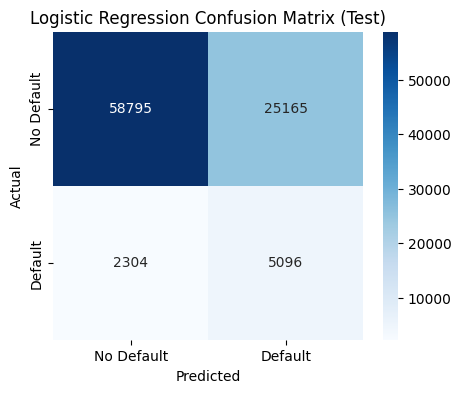

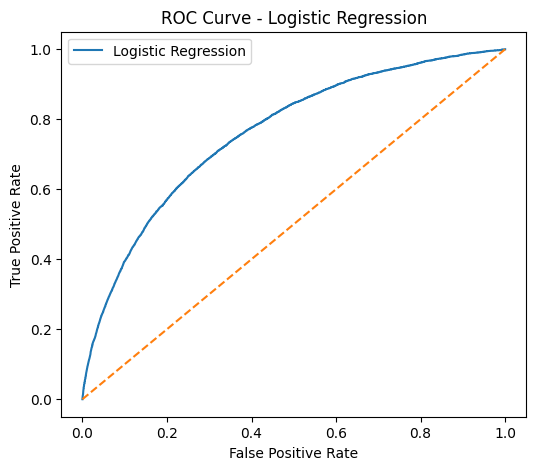

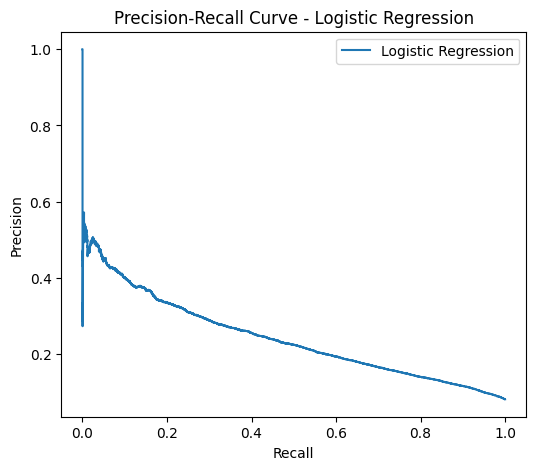

Logistic Regression does not support feature importances.

=== Error Analysis: Logistic Regression ===
False Negatives: 2304
False Positives: 25165


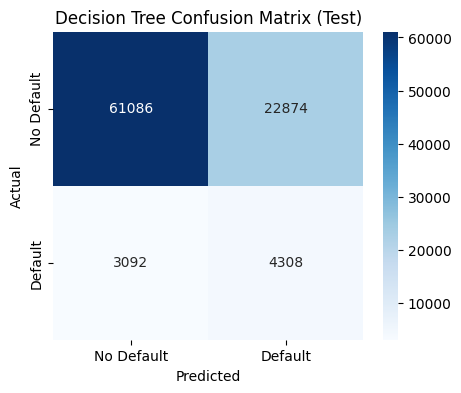

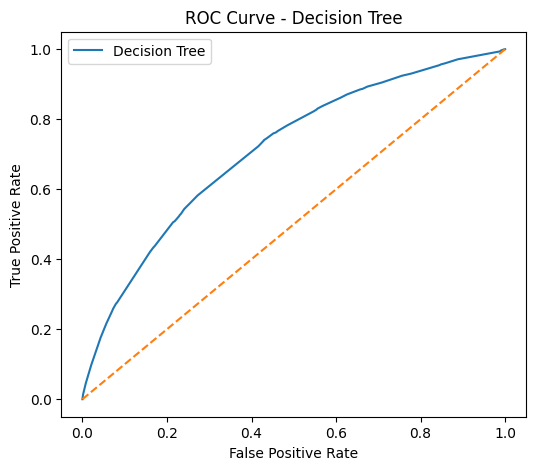

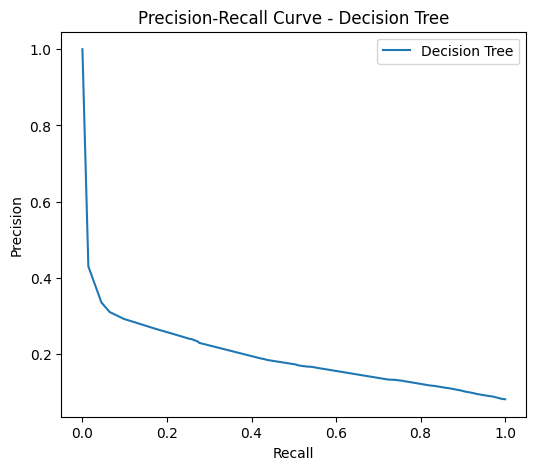

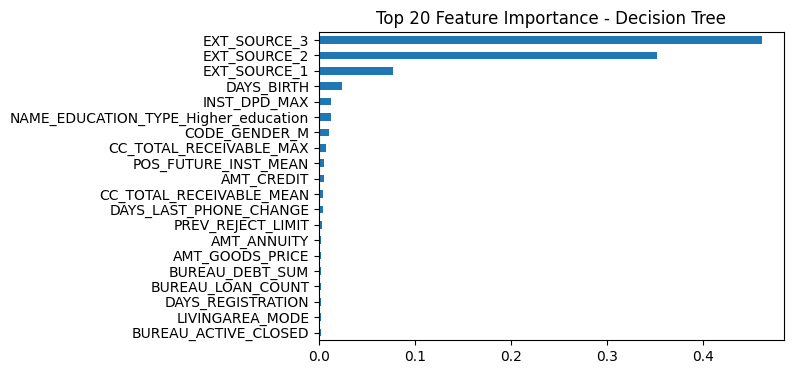


=== Error Analysis: Decision Tree ===
False Negatives: 3092
False Positives: 22874


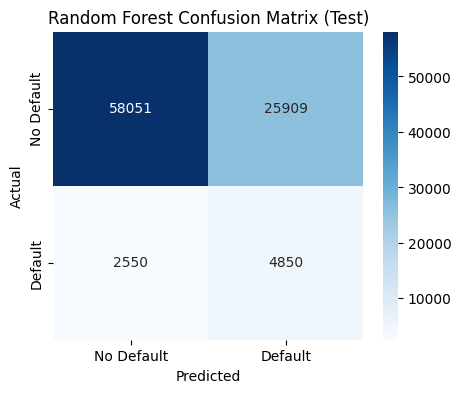

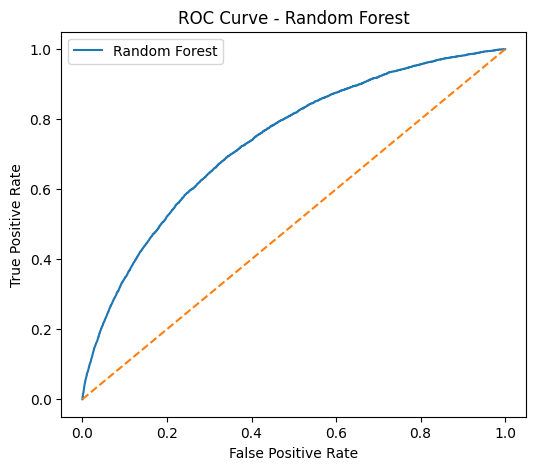

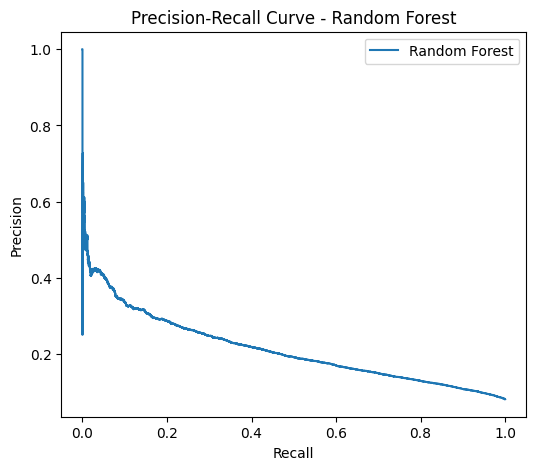

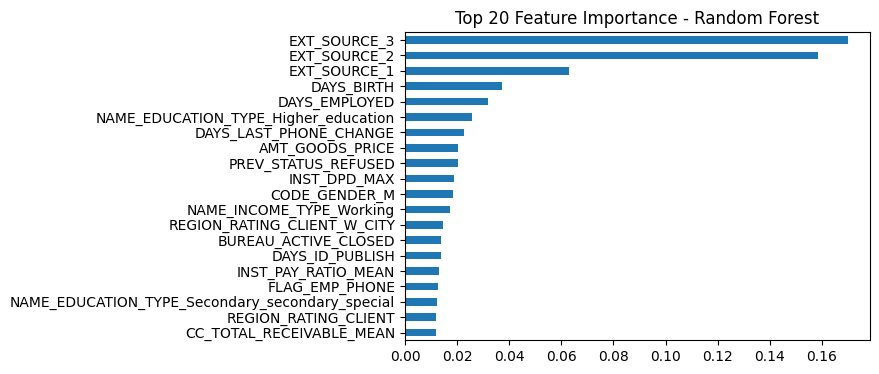


=== Error Analysis: Random Forest ===
False Negatives: 2550
False Positives: 25909


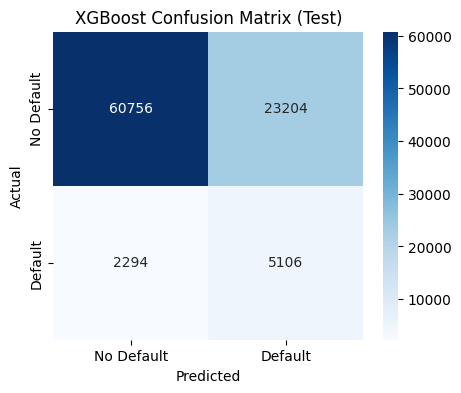

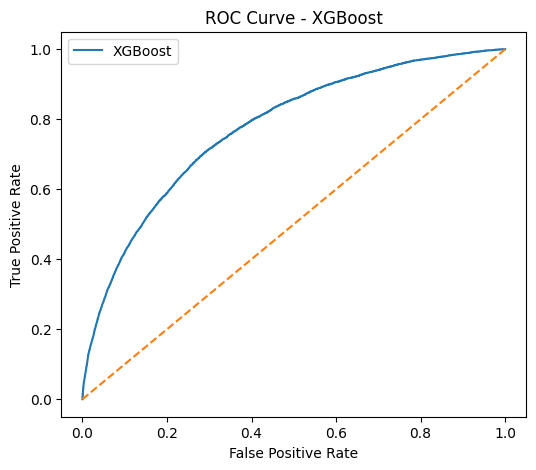

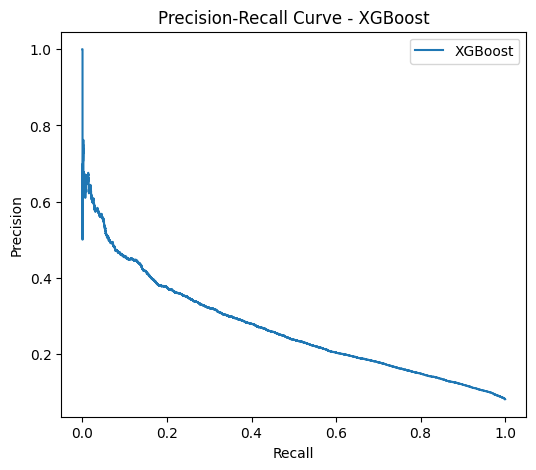

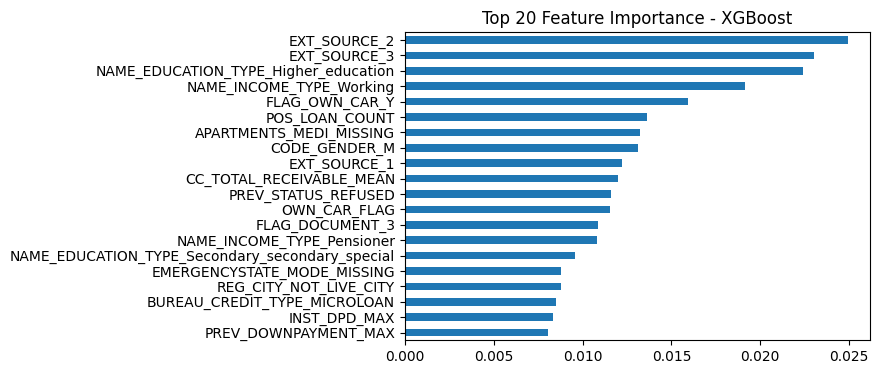


=== Error Analysis: XGBoost ===
False Negatives: 2294
False Positives: 23204


In [ ]:
# Dictionary of trained models
models = {
    "Logistic Regression": log_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}

# Run evaluation plots and error analysis for each model
for name, model in models.items():
    plot_confusion_matrix(model, X_test, y_test, name)
    plot_roc(model, X_test, y_test, name)
    plot_pr_curve(model, X_test, y_test, name)
    plot_feature_importance(model, X_train, name)
    error_analysis(model, X_test, y_test, name)